# imports

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import mlflow
import optuna
import matplotlib.pyplot as plt
import shap
from mlflow.models import infer_signature

# config

In [5]:
ASSET = "BTC"
INTERVAL = "1h"

# mlflow

In [6]:
mlflow.set_tracking_uri("http://localhost:5000")

experiment_name = f"{ASSET}_{INTERVAL}_Tuning_shap_2"
mlflow.set_experiment(experiment_name)

2026/05/09 13:45:02 INFO mlflow.tracking.fluent: Experiment with name 'BTC_1h_Tuning_shap_2' does not exist. Creating a new experiment.


<Experiment: artifact_location='/mlruns/12', creation_time=1778330702920, experiment_id='12', last_update_time=1778330702920, lifecycle_stage='active', name='BTC_1h_Tuning_shap_2', tags={}, trace_location=None, workspace='default'>

# load data

In [7]:
train_df = pd.read_parquet('../../../data/processed/train_btc_1h.parquet')
test_df = pd.read_parquet('../../../data/processed/test_btc_1h.parquet')

# splitting

In [8]:
features = [col for col in train_df.columns if col not in ['target_1h', 'target_direction']]
X_train = train_df[features]
y_train = train_df['target_direction']
X_test = test_df[features]
y_test = test_df['target_direction']

# func for tuning with mlflow,xgboost

In [9]:
def find_best_params(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    
    with mlflow.start_run(nested=True):
        mlflow.log_params(param)
        mlflow.log_metric("accuracy", accuracy)
        
    return accuracy

print("doone")    

doone


# hyperparameter tuning with optuna

In [10]:
print(" starting hyperparameter tuning with 50 trials...")

study = optuna.create_study(direction='maximize', study_name=f"XGB_Tuning_{ASSET}")

study.optimize(find_best_params, n_trials=50)

print(f"\n Tuning completed Best Accuracy found: {study.best_value * 100:.2f}%")
print(f"Winning Parameters: {study.best_params}")

[I 2026-05-09 13:45:03,178] A new study created in memory with name: XGB_Tuning_BTC


 starting hyperparameter tuning with 50 trials...


[I 2026-05-09 13:45:12,023] Trial 0 finished with value: 0.5259612685938816 and parameters: {'n_estimators': 243, 'max_depth': 3, 'learning_rate': 0.02337326439381596, 'subsample': 0.9914293394452043}. Best is trial 0 with value: 0.5259612685938816.


🏃 View run sincere-bug-876 at: http://localhost:5000/#/experiments/12/runs/6ed11055be4a4a639b5af5e5b05331f7
🧪 View experiment at: http://localhost:5000/#/experiments/12


[I 2026-05-09 13:45:13,328] Trial 1 finished with value: 0.5289550004677706 and parameters: {'n_estimators': 287, 'max_depth': 4, 'learning_rate': 0.012900769945242026, 'subsample': 0.7536172540346067}. Best is trial 1 with value: 0.5289550004677706.


...

🏃 View run nervous-mare-712 at: http://localhost:5000/#/experiments/12/runs/e4b0f12c9cd24fb08bb72b59a71b56a5
🧪 View experiment at: http://localhost:5000/#/experiments/12


[I 2026-05-09 13:46:24,254] Trial 48 finished with value: 0.5259612685938816 and parameters: {'n_estimators': 98, 'max_depth': 5, 'learning_rate': 0.010060657984928887, 'subsample': 0.6263662363328981}. Best is trial 33 with value: 0.5330713817943681.


🏃 View run zealous-fish-345 at: http://localhost:5000/#/experiments/12/runs/9cdb3292422f4bae89593a6a79281342
🧪 View experiment at: http://localhost:5000/#/experiments/12


[I 2026-05-09 13:46:25,502] Trial 49 finished with value: 0.5191318177565721 and parameters: {'n_estimators': 189, 'max_depth': 4, 'learning_rate': 0.2738147818410997, 'subsample': 0.7379547099292745}. Best is trial 33 with value: 0.5330713817943681.


🏃 View run stately-mole-905 at: http://localhost:5000/#/experiments/12/runs/b543ae0bf1e841a195d8b0a7f0392ff0
🧪 View experiment at: http://localhost:5000/#/experiments/12

 Tuning completed Best Accuracy found: 53.31%
Winning Parameters: {'n_estimators': 143, 'max_depth': 5, 'learning_rate': 0.033379386812244255, 'subsample': 0.9275475877631207}


# with using winning optuna param

In [11]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'

In [12]:
print(" training final model with best params...")
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

 training final model with best params...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.033379386812244255, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=143, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [13]:
print(" calc SHAP values")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

 calc SHAP values


# plots

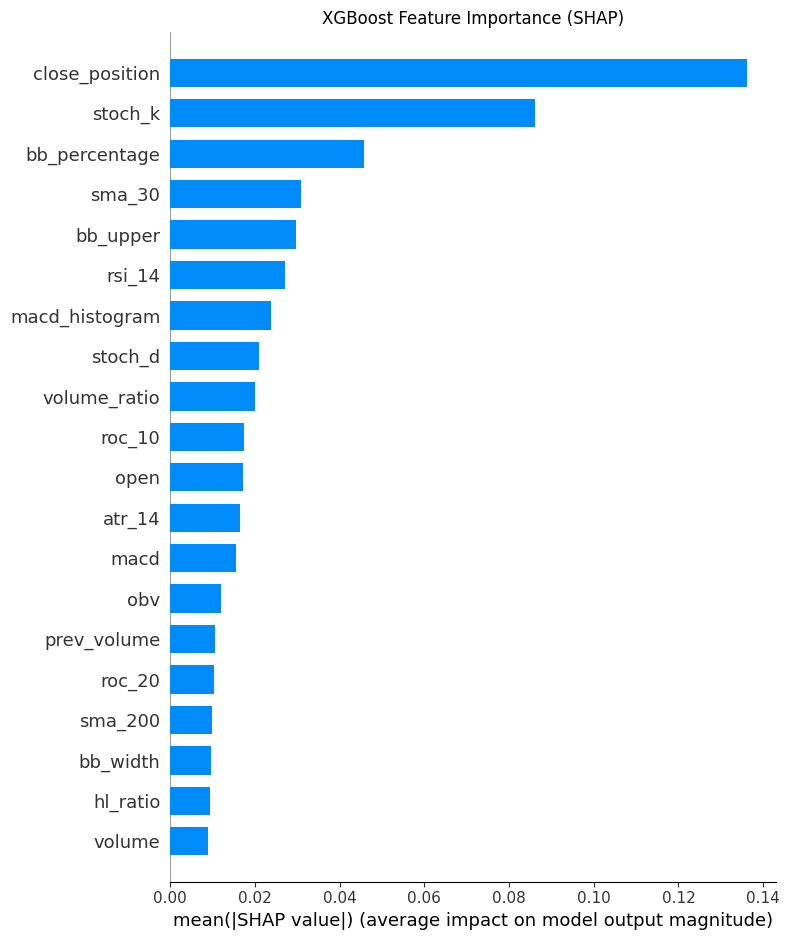

In [14]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

In [15]:
probs = final_model.predict_proba(X_test)
up_probabilities = probs[:, 1]

CONFIDENCE_THRESHOLD = 0.58

high_conviction_buys = up_probabilities > CONFIDENCE_THRESHOLD
total_signals = np.sum(high_conviction_buys)

if total_signals > 0:
    actual_outcomes = y_test[high_conviction_buys]
    winning_trades = np.sum(actual_outcomes == 1)
    win_rate = winning_trades / total_signals
    
    print(f"total 'High Confidence' buy signal: {total_signals}")
    print(f"win rate on these trades: {win_rate * 100:.2f}%")
else:
    print(f" model was never {CONFIDENCE_THRESHOLD*100}% confident")

total 'High Confidence' buy signal: 982
win rate on these trades: 54.99%


# saving  model to mlflow

In [20]:
with mlflow.start_run(run_name="test_recent_best_BTC_Model_registered"):
    
    mlflow.log_params(best_params)
    mlflow.log_metric("threshold_win_rate", win_rate)
    
    signature = infer_signature(X_train, final_model.predict(X_train))
    
    model_info = mlflow.xgboost.log_model(
        xgb_model=final_model,
        artifact_path="best_xgboost_model",
        signature=signature,
        registered_model_name="BTC_1h_Production_Model"
    )

print(f"model registered in mlflow")
print(f"model uri: {model_info.model_uri}")

2026/05/09 14:05:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'BTC_1h_Production_Model' already exists. Creating a new version of this model...
2026/05/09 14:05:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BTC_1h_Production_Model, version 3
Created version '3' of model 'BTC_1h_Production_Model'.


🏃 View run test_recent_best_BTC_Model_registered at: http://localhost:5000/#/experiments/12/runs/7e6bdd27655343a6b4b563c8db30ea3d
🧪 View experiment at: http://localhost:5000/#/experiments/12
model registered in mlflow
model uri: models:/m-64759a0cf35b4c96a3efb323d2e78c8a
